In [18]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import t as student_t
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [19]:
FILE_PATH = Path(
    r"C:\Users\brend\OneDrive\School OneDrive\2025 CCBL Trackman Data.xlsx"
)
OUTPUT_PATH = FILE_PATH.with_name("LocationPlus_v2.xlsx")

PITCH_TYPE_PRIORITY = ["MyPitchType", "TaggedPitchType", "AutoPitchType"]

TARGET_COLUMN = None

COUNT_EXPECTANCY_PRIOR = 200

GAME_RELIABILITY_PRIOR = 2.0

GROUP_COLUMN_PRIORITY = ["GameUID", "GameID", "Date"]
N_SPLITS = 5
RANDOM_STATE = 42

MIN_PITCHES_PITCHER = 50
MIN_PITCHES_PITCH_TYPE = 20

DUPLICATE_PITCH_KEEP = "last"

TEAM_FILTER = "FAL_COM"

ZONE_HALF_WIDTH = 0.83
ZONE_BOTTOM = 1.50
ZONE_TOP = 3.50

CCBL_CONSTANTS_SOURCE = "https://cdthoms.shinyapps.io/CCBL/"
CCBL_WOBA_CONSTANTS = {
    2025: {
        "leaguewOBA": 0.350,
        "wOBAScale": 1.209,
        "BB": 0.793,
        "HBP": 0.811,
        "Single": 0.988,
        "Double": 1.398,
        "Triple": 1.766,
        "HomeRun": 2.111,
        "RperPA": 0.122,
    },
    2026: {
        "leaguewOBA": 0.350,
        "wOBAScale": 1.162,
        "BB": 0.813,
        "HBP": 0.846,
        "Single": 0.998,
        "Double": 1.378,
        "Triple": 1.546,
        "HomeRun": 2.010,
        "RperPA": 0.127,
    },
}

In [20]:
PITCH_TYPE_MAP = {
    "ff": "Four-Seam",
    "fa": "Four-Seam",
    "fastball": "Four-Seam",
    "fourseam": "Four-Seam",
    "fourseamfastball": "Four-Seam",
    "fourseamfour-seam": "Four-Seam",
    "four-seam": "Four-Seam",
    "4-seam": "Four-Seam",
    "4seam": "Four-Seam",
    "twoseamfastball": "Two-Seam",
    "2s": "Two-Seam",
    "twoseam": "Two-Seam",
    "two-seam": "Two-Seam",
    "2-seam": "Two-Seam",
    "2seam": "Two-Seam",
    "changeup": "ChangeUp",
    "ch": "ChangeUp",
    "change-up": "ChangeUp",
    "change": "ChangeUp",
    "curveball": "Curveball",
    "cb": "Curveball",
    "curve": "Curveball",
    "slider": "Slider",
    "sl": "Slider",
    "sweeper": "Slider",
    "sw": "Slider",
    "cutter": "Cutter",
    "cuttter": "Cutter",
    "ct": "Cutter",
    "sinker": "Sinker",
    "si": "Sinker",
    "splitter": "Splitter",
    "splittter": "Splitter",
    "sp": "Splitter",
    "split-change": "Splitter",
    "splitchange": "Splitter",
    "knuckleball": "Knuckleball",
    "kn": "Knuckleball",
    "other": "Other",
    "undefined": "Undefined",
}

PUBLISHED_PITCH_TYPES = {
    "Four-Seam", "Two-Seam", "Sinker", "Cutter",
    "Slider", "Curveball", "ChangeUp", "Splitter", "Knuckleball",
}

SHAPE_CANDIDATES = [
    "RelSpeed",
    "InducedVertBreak",
    "HorzBreak",
    "SpinRate",
    "RelHeight",
    "RelSide",
    "Extension",
    "VertApprAngle",
    "HorzApprAngle",
]


def _clean_token(value: object) -> str:

    if pd.isna(value):
        return ""
    return re.sub(r"[\s_]", "", str(value).strip().lower())


def coalesce_duplicate_excel_columns(df: pd.DataFrame) -> pd.DataFrame:

    grouped: dict[str, list[str]] = {}
    for column in df.columns:
        base = re.sub(r"\.\d+$", "", str(column))
        grouped.setdefault(base, []).append(column)

    completed_columns: dict[str, pd.Series] = {}
    for base, columns in grouped.items():
        combined = df[columns[0]].astype("object").copy()
        for column in columns[1:]:
            missing = combined.isna()
            if missing.any():
                replacement = df[column].astype("object")
                combined.loc[missing] = replacement.loc[missing]
        completed_columns[base] = combined

    return pd.DataFrame(completed_columns, index=df.index).copy()


def deduplicate_pitch_rows(
    df: pd.DataFrame,
) -> tuple[pd.DataFrame, dict[str, int | str], pd.DataFrame]:
    diagnostics: dict[str, int | str] = {
        "Raw rows": len(df),
        "Rows with blank PitchUID": len(df),
        "Repeated PitchUIDs": 0,
        "Duplicate rows removed": 0,
        "Conflicting repeated PitchUIDs": 0,
        "Games containing repeated PitchUIDs": 0,
        "Duplicate row kept": DUPLICATE_PITCH_KEEP,
    }
    if "PitchUID" not in df.columns:
        diagnostics["Rows after PitchUID deduplication"] = len(df)
        return df, diagnostics, pd.DataFrame()
    if DUPLICATE_PITCH_KEEP not in {"first", "last"}:
        raise ValueError("DUPLICATE_PITCH_KEEP must be either 'first' or 'last'.")

    pitch_uid = df["PitchUID"].astype("string").str.strip()
    valid_uid = pitch_uid.notna() & pitch_uid.ne("")
    duplicated = valid_uid & pitch_uid.duplicated(keep=False)
    diagnostics["Rows with blank PitchUID"] = int((~valid_uid).sum())
    diagnostics["Repeated PitchUIDs"] = int(pitch_uid.loc[duplicated].nunique())
    conflict_candidates = [
        "GameUID", "GameID", "PitchNo", "Pitcher", "Balls", "Strikes",
        "PlateLocSide", "PlateLocHeight", "PitchCall", "PlayResult",
        *PITCH_TYPE_PRIORITY,
    ]
    conflict_columns = [column for column in conflict_candidates if column in df.columns]
    conflicts = pd.Series(dtype=bool)
    if duplicated.any() and conflict_columns:
        duplicate_work = df.loc[duplicated, conflict_columns].copy()
        duplicate_work["_PitchUID"] = pitch_uid.loc[duplicated]
        conflicts = (
            duplicate_work.groupby("_PitchUID", dropna=False)[conflict_columns]
            .nunique(dropna=False).gt(1).any(axis=1)
        )
        diagnostics["Conflicting repeated PitchUIDs"] = int(conflicts.sum())
    game_column = next((c for c in ["GameUID", "GameID"] if c in df.columns), None)
    if duplicated.any() and game_column is not None:
        diagnostics["Games containing repeated PitchUIDs"] = int(
            df.loc[duplicated, game_column].nunique(dropna=True)
        )

    remove = valid_uid & pitch_uid.duplicated(keep=DUPLICATE_PITCH_KEEP)
    diagnostics["Duplicate rows removed"] = int(remove.sum())
    cleaned = df.loc[~remove].copy()
    diagnostics["Rows after PitchUID deduplication"] = len(cleaned)
    if remove.any():
        warnings.warn(
            f"Removed {remove.sum():,} duplicate pitch rows across "
            f"{diagnostics['Repeated PitchUIDs']:,} repeated PitchUIDs; "
            f"kept the {DUPLICATE_PITCH_KEEP} occurrence."
        )

    conflict_details: list[dict[str, object]] = []
    if not conflicts.empty and conflicts.any():
        kept_mask = valid_uid & ~remove
        for uid in conflicts.index[conflicts]:
            uid_rows = df.index[pitch_uid.eq(uid)]
            kept_index = df.index[kept_mask & pitch_uid.eq(uid)][0]
            differing = [
                column for column in conflict_columns
                if df.loc[uid_rows, column].nunique(dropna=False) > 1
            ]
            kept_row = df.loc[kept_index]
            detail = {
                "PitchUID": uid,
                "Occurrences": len(uid_rows),
                "ConflictingColumns": ", ".join(differing),
                "KeptOccurrence": DUPLICATE_PITCH_KEEP,
            }
            for column in [
                "GameUID", "GameID", "PitchNo", "Pitcher", "PitchCall",
                "PlayResult", "KorBB", "Balls", "Strikes",
                "PlateLocSide", "PlateLocHeight", *PITCH_TYPE_PRIORITY,
            ]:
                if column in df.columns:
                    detail[f"Kept_{column}"] = kept_row[column]
            conflict_details.append(detail)
    return cleaned, diagnostics, pd.DataFrame(conflict_details)


def normalize_hand(value: object) -> str:
    token = _clean_token(value)
    if token in {"r", "right", "righthanded", "right-handed"}:
        return "R"
    if token in {"l", "left", "lefthanded", "left-handed"}:
        return "L"
    if token in {"s", "switch", "switchhitter"}:
        return "S"
    return "Unknown"


def normalize_pitch_type(value: object) -> str:
    token = _clean_token(value).replace("_", "")

    if token in PITCH_TYPE_MAP:
        return PITCH_TYPE_MAP[token]
    no_hyphen = token.replace("-", "")
    for raw, canonical in PITCH_TYPE_MAP.items():
        if raw.replace("-", "") == no_hyphen:
            return canonical
    if not token:
        return "Undefined"
    return str(value).strip()


def choose_first_available(df: pd.DataFrame, candidates: list[str]) -> pd.Series:
    result = pd.Series(pd.NA, index=df.index, dtype="object")
    found = False
    for column in candidates:
        if column in df.columns:
            found = True
            usable = df[column].notna() & df[column].astype(str).str.strip().ne("")
            result.loc[result.isna() & usable] = df.loc[result.isna() & usable, column]
    if not found:
        raise KeyError(f"None of these required columns was found: {candidates}")
    return result


def derive_supported_season(df: pd.DataFrame) -> tuple[pd.Series, pd.Series]:

    supported = set(CCBL_WOBA_CONSTANTS)
    season = pd.Series(pd.NA, index=df.index, dtype="Int64")
    source = pd.Series(pd.NA, index=df.index, dtype="string")

    for column in ["Date", "LocalDateTime", "UTCDate", "UTCDateTime"]:
        if column not in df.columns:
            continue
        parsed = pd.to_datetime(df[column], errors="coerce", utc=True)
        years = parsed.dt.year.astype("Int64")
        usable = season.isna() & years.isin(supported)
        season.loc[usable] = years.loc[usable]
        source.loc[usable] = column

    if "GameID" in df.columns:
        game_year = pd.to_numeric(
            df["GameID"].astype("string").str.extract(r"^(20\d{2})", expand=False),
            errors="coerce",
        ).astype("Int64")
        usable = season.isna() & game_year.isin(supported)
        season.loc[usable] = game_year.loc[usable]
        source.loc[usable] = "GameID"

    return season, source


def infer_pre_pitch_counts(df: pd.DataFrame) -> tuple[pd.Series, pd.Series]:

    balls_out = pd.Series(np.nan, index=df.index, dtype=float)
    strikes_out = pd.Series(np.nan, index=df.index, dtype=float)

    sort_columns = [c for c in ["_Group", "PitchNo", "_RowOrder"] if c in df.columns]
    work = df.sort_values(sort_columns, kind="stable")

    for _, game in work.groupby("_Group", sort=False, dropna=False):
        balls = 0
        strikes = 0
        previous_pitch_of_pa = None

        for idx, row in game.iterrows():
            pitch_of_pa = pd.to_numeric(row.get("PitchofPA", np.nan), errors="coerce")
            if (
                previous_pitch_of_pa is None
                or pitch_of_pa == 1
                or (
                    pd.notna(pitch_of_pa)
                    and pd.notna(previous_pitch_of_pa)
                    and pitch_of_pa <= previous_pitch_of_pa
                )
            ):
                balls, strikes = 0, 0

            balls_out.at[idx] = balls
            strikes_out.at[idx] = strikes

            call = _clean_token(row.get("PitchCall", ""))
            if call in {"ballcalled", "ballintentional", "ballindirt", "pitchout"}:
                balls = min(balls + 1, 3)
            elif call in {"strikecalled", "strikeswinging", "strikeswingingblocked"}:
                strikes = min(strikes + 1, 2)
            elif call in {
                "foulball",
                "foulballfieldable",
                "foulballnotfieldable",
                "foultip",
            }:
                if strikes < 2:
                    strikes += 1

            previous_pitch_of_pa = pitch_of_pa

    return balls_out, strikes_out


BALL_CALLS = {"ballcalled", "ballintentional", "ballindirt", "pitchout"}
STRIKE_CALLS = {"strikecalled", "strikeswinging", "strikeswingingblocked", "foultip"}
FOUL_CALLS = {"foulball", "foulballfieldable", "foulballnotfieldable"}
IN_PLAY_CALLS = {"inplay", "inplaynoout", "inplayrun"}


def build_pa_keys(df: pd.DataFrame) -> pd.Series:

    half_column = next(
        (column for column in ["Top/Bottom", "TopBottom", "InningHalf"] if column in df.columns),
        None,
    )
    explicit_columns = ["_Group", "Inning", half_column, "PAofInning"]
    if half_column is not None and all(column in df.columns for column in explicit_columns):
        explicit = df[explicit_columns]
        if explicit.notna().all(axis=None):
            return (
                df["_Group"].astype("string")
                + "|I" + df["Inning"].astype("string")
                + "|" + df[half_column].astype("string")
                + "|PA" + df["PAofInning"].astype("string")
            )

    if "PAofInning" in df.columns:
        sort_columns = [c for c in ["_Group", "PitchNo", "_RowOrder"] if c in df.columns]
        work = df.sort_values(sort_columns, kind="stable").copy()
        pa_of_inning = pd.to_numeric(work["PAofInning"], errors="coerce")
        if pa_of_inning.notna().all():
            previous_pa = pa_of_inning.groupby(work["_Group"], sort=False).shift()
            new_half = previous_pa.notna() & pa_of_inning.lt(previous_pa)
            half_number = new_half.groupby(work["_Group"], sort=False).cumsum()
            keys = pd.Series(pd.NA, index=df.index, dtype="string")
            keys.loc[work.index] = (
                work["_Group"].astype("string")
                + "|H" + half_number.astype("string")
                + "|PA" + pa_of_inning.astype("Int64").astype("string")
            )
            keys.attrs["method"] = "Game + inferred half-inning + PAofInning"
            return keys

    if "PitchofPA" not in df.columns:
        raise KeyError(
            "PitchofPA is required for the count-dependent run-value target."
        )

    sort_columns = [c for c in ["_Group", "PitchNo", "_RowOrder"] if c in df.columns]
    work = df.sort_values(sort_columns, kind="stable").copy()
    pitch_of_pa = pd.to_numeric(work["PitchofPA"], errors="coerce")
    previous = pitch_of_pa.groupby(work["_Group"], sort=False).shift()
    new_pa = previous.isna() | pitch_of_pa.eq(1) | (
        pitch_of_pa.notna() & previous.notna() & pitch_of_pa.lt(previous)
    )
    pa_number = new_pa.groupby(work["_Group"], sort=False).cumsum().astype("Int64")

    keys = pd.Series(pd.NA, index=df.index, dtype="string")
    keys.loc[work.index] = work["_Group"].astype("string") + "|PA" + pa_number.astype("string")
    keys.attrs["method"] = "PitchofPA reset inference"
    return keys


def event_run_values_for_season(season: int) -> dict[str, float]:

    available = sorted(CCBL_WOBA_CONSTANTS)
    selected = season if season in CCBL_WOBA_CONSTANTS else min(
        available, key=lambda year: abs(year - season)
    )
    constants = CCBL_WOBA_CONSTANTS[selected]

    def to_runs(weight: float) -> float:
        return constants["RperPA"] + (
            weight - constants["leaguewOBA"]
        ) / constants["wOBAScale"]

    return {
        "Out": to_runs(0.0),
        "BB": to_runs(constants["BB"]),
        "HBP": to_runs(constants["HBP"]),
        "Single": to_runs(constants["Single"]),
        "Double": to_runs(constants["Double"]),
        "Triple": to_runs(constants["Triple"]),
        "HomeRun": to_runs(constants["HomeRun"]),
    }


def identify_terminal_events(df: pd.DataFrame) -> pd.Series:

    call = df.get("PitchCall", pd.Series("", index=df.index)).map(_clean_token)
    result = df.get("PlayResult", pd.Series("", index=df.index)).map(_clean_token)
    korbb = df.get("KorBB", pd.Series("", index=df.index)).map(_clean_token)
    pa_result = df.get("PAResult", pd.Series("", index=df.index)).map(_clean_token)

    category = pd.Series(pd.NA, index=df.index, dtype="string")
    result_map = {
        "out": "Out",
        "fielderschoice": "Out",
        "fielderschoiceout": "Out",
        "sacrifice": "Out",
        "sacrificefly": "Out",
        "error": "Out",
        "single": "Single",
        "double": "Double",
        "triple": "Triple",
        "homerun": "HomeRun",
    }
    mapped_result = result.map(result_map)
    category.loc[mapped_result.notna()] = mapped_result.loc[mapped_result.notna()]

    if "OutsOnPlay" in df.columns:
        outs_on_play = pd.to_numeric(df["OutsOnPlay"], errors="coerce")
        category.loc[
            category.isna() & call.isin(IN_PLAY_CALLS) & outs_on_play.gt(0)
        ] = "Out"

    category.loc[call.eq("hitbypitch")] = "HBP"
    walk_result = korbb.isin({"walk", "bb", "baseonballs", "intentionalwalk"}) | pa_result.isin(
        {"walk", "bb", "baseonballs", "intentionalwalk"}
    )
    strikeout_result = korbb.isin({"strikeout", "so", "k"}) | pa_result.isin(
        {"strikeout", "so", "k"}
    )

    category.loc[walk_result] = "BB"
    category.loc[strikeout_result] = "Out"

    category.loc[df["Balls"].eq(3) & call.isin(BALL_CALLS)] = "BB"
    category.loc[df["Strikes"].eq(2) & call.isin(STRIKE_CALLS)] = "Out"

    if "PitchNo" in df.columns:
        pitch_order = pd.to_numeric(df["PitchNo"], errors="coerce")
    else:
        pitch_order = pd.to_numeric(df["_RowOrder"], errors="coerce")
    candidate_order = pitch_order.where(category.notna())
    last_candidate = candidate_order.groupby(df["_PAKey"]).transform("max")
    is_terminal_row = category.notna() & candidate_order.eq(last_candidate)
    return category.where(is_terminal_row)


def build_count_dependent_run_value(
    df: pd.DataFrame,
) -> tuple[pd.Series, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    df = df.copy()
    df["_TerminalEvent"] = identify_terminal_events(df)

    season_event_values: dict[tuple[int, str], float] = {}
    for season in sorted(df["Season"].dropna().astype(int).unique()):
        for event, value in event_run_values_for_season(season).items():
            season_event_values[(season, event)] = value

    terminal_value = pd.Series(np.nan, index=df.index, dtype=float)
    for (season, event), value in season_event_values.items():
        mask = df["Season"].eq(season) & df["_TerminalEvent"].eq(event)
        terminal_value.loc[mask] = value

    df["_TerminalValue"] = terminal_value
    pa_outcome = df.groupby("_PAKey")["_TerminalValue"].transform("max")
    df["_PAOutcomeValue"] = pa_outcome

    count_samples = (
        df.loc[df["_PAOutcomeValue"].notna(), ["_PAKey", "Season", "Count", "_PAOutcomeValue"]]
        .drop_duplicates(["_PAKey", "Count"])
        .copy()
    )
    if count_samples.empty:
        raise ValueError("No completed plate appearances were available for count values.")

    overall = (
        count_samples.groupby("Count")["_PAOutcomeValue"]
        .agg(OverallMean="mean", OverallN="size")
        .reset_index()
    )
    by_season = (
        count_samples.groupby(["Season", "Count"])["_PAOutcomeValue"]
        .agg(SeasonMean="mean", SeasonN="size")
        .reset_index()
        .merge(overall, on="Count", how="left")
    )
    by_season["CountRunValue"] = (
        by_season["SeasonN"] * by_season["SeasonMean"]
        + COUNT_EXPECTANCY_PRIOR * by_season["OverallMean"]
    ) / (by_season["SeasonN"] + COUNT_EXPECTANCY_PRIOR)
    count_table = by_season[
        ["Season", "Count", "SeasonN", "SeasonMean", "OverallN", "OverallMean", "CountRunValue"]
    ].sort_values(["Season", "Count"])

    lookup = count_table.set_index(["Season", "Count"])["CountRunValue"]
    before_keys = pd.MultiIndex.from_arrays([df["Season"], df["Count"]])
    before_value = pd.Series(lookup.reindex(before_keys).to_numpy(), index=df.index, dtype=float)

    call = df.get("PitchCall", pd.Series("", index=df.index)).map(_clean_token)
    next_balls = df["Balls"].copy()
    next_strikes = df["Strikes"].copy()
    nonterminal = df["_TerminalEvent"].isna()

    ball_mask = nonterminal & call.isin(BALL_CALLS) & df["Balls"].lt(3)
    strike_mask = nonterminal & call.isin(STRIKE_CALLS) & df["Strikes"].lt(2)
    foul_add_strike = nonterminal & call.isin(FOUL_CALLS) & df["Strikes"].lt(2)
    foul_hold = nonterminal & call.isin(FOUL_CALLS) & df["Strikes"].eq(2)

    next_balls.loc[ball_mask] += 1
    next_strikes.loc[strike_mask | foul_add_strike] += 1
    valid_nonterminal = ball_mask | strike_mask | foul_add_strike | foul_hold

    post_count = (
        next_balls.fillna(-1).astype(int).astype(str)
        + "-"
        + next_strikes.fillna(-1).astype(int).astype(str)
    )
    after_keys = pd.MultiIndex.from_arrays([df["Season"], post_count])
    after_count_value = pd.Series(lookup.reindex(after_keys).to_numpy(), index=df.index, dtype=float)

    after_value = pd.Series(np.nan, index=df.index, dtype=float)
    after_value.loc[valid_nonterminal] = after_count_value.loc[valid_nonterminal]
    terminal_mask = df["_TerminalEvent"].notna() & df["_TerminalValue"].notna()
    after_value.loc[terminal_mask] = df.loc[terminal_mask, "_TerminalValue"]

    target = after_value - before_value
    return target, count_table, before_value, after_value, df["_TerminalEvent"]


def build_missing_target_audit(df: pd.DataFrame) -> pd.DataFrame:
    missing = df.loc[df["TargetRV"].isna()].copy()
    if missing.empty:
        return pd.DataFrame(columns=[
            "Season", "Reason", "PitchCall", "PlayResult", "KorBB",
            "IsLastTrackedPitch", "Pitches",
        ])
    call = missing.get("PitchCall", pd.Series("", index=missing.index)).map(_clean_token)
    result = missing.get("PlayResult", pd.Series("", index=missing.index)).map(_clean_token)
    korbb = missing.get("KorBB", pd.Series("", index=missing.index)).map(_clean_token)
    reason = pd.Series("Unrecognized result or count transition", index=missing.index)
    reason.loc[call.eq("")] = "Missing PitchCall"
    reason.loc[call.isin(IN_PLAY_CALLS) & result.isin({"", "undefined"})] = (
        "In-play pitch missing PlayResult"
    )
    reason.loc[korbb.isin({"walk", "bb", "baseonballs", "intentionalwalk"})] = (
        "Walk in KorBB was not assigned"
    )
    reason.loc[korbb.isin({"strikeout", "so", "k"})] = (
        "Strikeout in KorBB was not assigned"
    )
    missing["Reason"] = reason
    if "PitchNo" in df.columns:
        full_order = pd.to_numeric(df["PitchNo"], errors="coerce")
    else:
        full_order = pd.to_numeric(df["_RowOrder"], errors="coerce")
    final_order = full_order.groupby(df["_PAKey"]).transform("max")
    missing["IsLastTrackedPitch"] = full_order.loc[missing.index].eq(
        final_order.loc[missing.index]
    )
    audit_columns = ["Season", "Reason", "PitchCall", "PlayResult", "KorBB"]
    for column in audit_columns:
        if column not in missing.columns:
            missing[column] = "<blank>"
        else:
            missing[column] = (
                missing[column].astype("string").fillna("<blank>").replace("", "<blank>")
            )
    return (
        missing.groupby(audit_columns + ["IsLastTrackedPitch"], dropna=False)
        .size().rename("Pitches").reset_index()
        .sort_values("Pitches", ascending=False)
    )


def prepare_data(
    raw: pd.DataFrame,
) -> tuple[
    pd.DataFrame, str, bool, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame
]:
    df = coalesce_duplicate_excel_columns(raw)
    df["_RowOrder"] = np.arange(len(df))
    df, quality, duplicate_conflicts = deduplicate_pitch_rows(df)

    required = ["Pitcher", "PitcherThrows", "BatterSide", "PlateLocHeight", "PlateLocSide"]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    group_column = next((c for c in GROUP_COLUMN_PRIORITY if c in df.columns), None)
    if group_column is None:
        raise KeyError(
            "A grouped holdout requires one of these columns: "
            f"{GROUP_COLUMN_PRIORITY}"
        )
    df["_Group"] = df[group_column].where(df[group_column].notna(), pd.NA).astype("string")

    df["Season"], df["_SeasonSource"] = derive_supported_season(df)
    invalid_season_rows = df["Season"].isna()
    quality["Unsupported-season rows removed"] = int(invalid_season_rows.sum())
    if invalid_season_rows.any():
        warnings.warn(
            f"Excluding {invalid_season_rows.sum():,} rows whose season could not "
            f"be recovered as one of {sorted(CCBL_WOBA_CONSTANTS)}."
        )
        df = df.loc[~invalid_season_rows].copy()
    if df.empty:
        raise ValueError("No rows remain after supported-season validation.")

    if "Stadium" in df.columns:
        park = df["Stadium"]
    elif "HomeTeam" in df.columns:
        park = df["HomeTeam"]
    else:
        park = pd.Series("Unknown", index=df.index)
    df["Park"] = park.fillna("Unknown").astype(str)

    df["PitchType"] = choose_first_available(df, PITCH_TYPE_PRIORITY).map(normalize_pitch_type)
    df["PitcherHand"] = df["PitcherThrows"].map(normalize_hand)
    df["BatterHand"] = df["BatterSide"].map(normalize_hand)

    for column in ["PlateLocHeight", "PlateLocSide"] + SHAPE_CANDIDATES:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")

    counts_inferred = not {"Balls", "Strikes"}.issubset(df.columns)
    if counts_inferred:
        warnings.warn(
            "Balls and/or Strikes were not found. Pre-pitch counts are being "
            "inferred from PitchofPA and PitchCall."
        )
        df["Balls"], df["Strikes"] = infer_pre_pitch_counts(df)
    else:
        df["Balls"] = pd.to_numeric(df["Balls"], errors="coerce")
        df["Strikes"] = pd.to_numeric(df["Strikes"], errors="coerce")

    df["Balls"] = df["Balls"].clip(0, 3)
    df["Strikes"] = df["Strikes"].clip(0, 2)
    df["Count"] = (
        df["Balls"].fillna(-1).astype(int).astype(str)
        + "-"
        + df["Strikes"].fillna(-1).astype(int).astype(str)
    )
    pa_keys = build_pa_keys(df)
    quality["PA key method"] = pa_keys.attrs.get(
        "method", "Explicit Inning + half-inning + PAofInning"
    )
    df["_PAKey"] = pa_keys

    df["InZone"] = (
        df["PlateLocSide"].between(-ZONE_HALF_WIDTH, ZONE_HALF_WIDTH)
        & df["PlateLocHeight"].between(ZONE_BOTTOM, ZONE_TOP)
    ).astype(int)

    df["LocSide2"] = df["PlateLocSide"] ** 2
    df["LocHeight2"] = df["PlateLocHeight"] ** 2
    df["LocInteraction"] = df["PlateLocSide"] * df["PlateLocHeight"]

    if TARGET_COLUMN is not None:
        if TARGET_COLUMN not in df.columns:
            raise KeyError(f"TARGET_COLUMN '{TARGET_COLUMN}' was not found.")
        df["TargetRV"] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
        target_name = TARGET_COLUMN
        count_table = pd.DataFrame()
        df["PreCountRV"] = np.nan
        df["PostStateRV"] = np.nan
        df["TerminalEvent"] = pd.NA
    else:
        (
            df["TargetRV"],
            count_table,
            df["PreCountRV"],
            df["PostStateRV"],
            df["TerminalEvent"],
        ) = build_count_dependent_run_value(df)
        target_name = (
            "Count-dependent pitch RV using 2025-26 CCBL wOBA constants "
            "and empirical count expectancy"
        )

    missing_target_audit = build_missing_target_audit(df)

    eligibility = {
        "Missing pitcher": df["Pitcher"].isna(),
        "Missing pitch type": df["PitchType"].isna(),
        "Missing target RV": df["TargetRV"].isna(),
        "Invalid horizontal location": ~df["PlateLocSide"].between(-5.0, 5.0),
        "Invalid vertical location": ~df["PlateLocHeight"].between(-2.0, 7.0),
        "Missing count": df["Balls"].isna() | df["Strikes"].isna(),
        "Missing holdout group": df["_Group"].isna(),
        "Missing PA key": df["_PAKey"].isna(),
    }
    for label, mask in eligibility.items():
        quality[f"Model exclusions - {label}"] = int(mask.sum())
    model_rows = ~pd.DataFrame(eligibility).any(axis=1)
    df = df.loc[model_rows].copy()
    quality["Final model pitches"] = len(df)
    data_quality = pd.DataFrame(
        {"Metric": list(quality.keys()), "Value": list(quality.values())}
    )

    if df.empty:
        raise ValueError("No usable pitch rows remain after data preparation.")
    if df["_Group"].nunique() < 2:
        raise ValueError("Grouped validation requires at least two unique games/groups.")

    return (
        df, target_name, counts_inferred, count_table, data_quality,
        duplicate_conflicts, missing_target_audit,
    )




In [21]:
CONTEXT_CATEGORICAL = [
    "PitchType",
    "Count",
    "BatterHand",
    "PitcherHand",
    "Season",
    "Park",
]
LOCATION_NUMERIC = ["PlateLocSide", "PlateLocHeight"]
ZONE_NUMERIC = ["InZone", "PlateLocSide", "PlateLocHeight", "LocSide2", "LocHeight2", "LocInteraction"]


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_preprocessor(numeric_columns: list[str], categorical_columns: list[str]) -> ColumnTransformer:
    numeric_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )
    transformers = []
    if numeric_columns:
        transformers.append(("numeric", numeric_pipe, numeric_columns))
    if categorical_columns:
        transformers.append(("categorical", categorical_pipe, categorical_columns))
    if not transformers:
        raise ValueError("At least one numeric or categorical feature is required.")
    return ColumnTransformer(transformers, remainder="drop")


def make_xgb_pipeline(numeric_columns: list[str], categorical_columns: list[str]) -> Pipeline:
    return Pipeline(
        [
            ("prep", make_preprocessor(numeric_columns, categorical_columns)),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    n_estimators=450,
                    learning_rate=0.035,
                    max_depth=4,
                    min_child_weight=20,
                    subsample=0.80,
                    colsample_bytree=0.85,
                    reg_alpha=0.05,
                    reg_lambda=2.0,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    tree_method="hist",
                ),
            ),
        ]
    )


def make_ridge_pipeline(numeric_columns: list[str], categorical_columns: list[str]) -> Pipeline:
    return Pipeline(
        [
            ("prep", make_preprocessor(numeric_columns, categorical_columns)),
            ("model", Ridge(alpha=10.0)),
        ]
    )


def grouped_oof_predict(
    df: pd.DataFrame,
    feature_columns: list[str],
    pipeline_factory,
    folds: list[tuple[np.ndarray, np.ndarray]],
) -> np.ndarray:
    predictions = np.full(len(df), np.nan, dtype=float)
    X = df[feature_columns]
    y = df["TargetRV"].to_numpy()

    for fold_number, (train_index, test_index) in enumerate(folds, start=1):
        model = pipeline_factory()
        model.fit(X.iloc[train_index], y[train_index])
        predictions[test_index] = model.predict(X.iloc[test_index])
        print(f"  completed fold {fold_number}/{len(folds)}")

    if np.isnan(predictions).any():
        raise RuntimeError("At least one row did not receive an OOF prediction.")
    return predictions


def grouped_mean_baseline(y: np.ndarray, folds: list[tuple[np.ndarray, np.ndarray]]) -> np.ndarray:
    predictions = np.full(len(y), np.nan, dtype=float)
    for train_index, test_index in folds:
        predictions[test_index] = np.mean(y[train_index])
    return predictions


def regression_metrics(name: str, actual: np.ndarray, predicted: np.ndarray) -> dict[str, float | str]:
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }


def fit_oof_models(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    n_splits = min(N_SPLITS, df["_Group"].nunique())
    splitter = GroupKFold(n_splits=n_splits)
    folds = list(splitter.split(df, df["TargetRV"], groups=df["_Group"]))

    context_features = CONTEXT_CATEGORICAL
    zone_features = CONTEXT_CATEGORICAL + ZONE_NUMERIC
    location_features = CONTEXT_CATEGORICAL + LOCATION_NUMERIC
    shape_columns = [column for column in SHAPE_CANDIDATES if column in df.columns]
    full_features = location_features + shape_columns

    print("Fitting context-only model...")
    df["OOF_ContextRV"] = grouped_oof_predict(
        df,
        context_features,
        lambda: make_xgb_pipeline([], CONTEXT_CATEGORICAL),
        folds,
    )

    print("Fitting simple zone/polynomial baseline...")
    df["OOF_ZoneBaselineRV"] = grouped_oof_predict(
        df,
        zone_features,
        lambda: make_ridge_pipeline(ZONE_NUMERIC, CONTEXT_CATEGORICAL),
        folds,
    )

    print("Fitting continuous-location XGBoost model...")
    df["OOF_LocationRV"] = grouped_oof_predict(
        df,
        location_features,
        lambda: make_xgb_pipeline(LOCATION_NUMERIC, CONTEXT_CATEGORICAL),
        folds,
    )

    if shape_columns:
        print("Fitting separate location + pitch-shape comparison model...")
        df["OOF_FullRV"] = grouped_oof_predict(
            df,
            full_features,
            lambda: make_xgb_pipeline(LOCATION_NUMERIC + shape_columns, CONTEXT_CATEGORICAL),
            folds,
        )
    else:
        warnings.warn("No pitch-shape columns were found; the Full model was skipped.")
        df["OOF_FullRV"] = np.nan

    actual = df["TargetRV"].to_numpy()
    mean_prediction = grouped_mean_baseline(actual, folds)
    performance_rows = [
        regression_metrics("Grouped training-mean baseline", actual, mean_prediction),
        regression_metrics("Context only", actual, df["OOF_ContextRV"].to_numpy()),
        regression_metrics("Simple zone/polynomial baseline", actual, df["OOF_ZoneBaselineRV"].to_numpy()),
        regression_metrics("Location XGBoost", actual, df["OOF_LocationRV"].to_numpy()),
    ]
    if shape_columns:
        performance_rows.append(
            regression_metrics("Location + shape (comparison only)", actual, df["OOF_FullRV"].to_numpy())
        )

    performance = pd.DataFrame(performance_rows)

    df["LocationValue"] = df["OOF_ContextRV"] - df["OOF_LocationRV"]
    df["ZoneBaselineValue"] = df["OOF_ContextRV"] - df["OOF_ZoneBaselineRV"]

    value_mean = df["LocationValue"].mean()
    value_std = df["LocationValue"].std(ddof=0)
    if not np.isfinite(value_std) or value_std == 0:
        raise RuntimeError("LocationValue has zero variance; Location+ cannot be standardized.")

    df["Location+_Pitch"] = 100.0 + 15.0 * (df["LocationValue"] - value_mean) / value_std

    zone_value_std = df["ZoneBaselineValue"].std(ddof=0)
    if np.isfinite(zone_value_std) and zone_value_std > 0:
        df["ZoneBaseline+_Pitch"] = (
            100.0
            + 15.0
            * (df["ZoneBaselineValue"] - df["ZoneBaselineValue"].mean())
            / zone_value_std
        )
    else:
        df["ZoneBaseline+_Pitch"] = 100.0

    return df, performance, shape_columns


def fit_forward_season_validation(
    df: pd.DataFrame, shape_columns: list[str]
) -> pd.DataFrame:
    seasons = sorted(int(year) for year in df["Season"].dropna().astype(int).unique())
    if len(seasons) < 2:
        return pd.DataFrame(
            [{"Model": "Forward validation unavailable", "Reason": "Only one season present"}]
        )

    test_season = seasons[-1]
    train_mask = df["Season"].astype(int).lt(test_season)
    test_mask = df["Season"].astype(int).eq(test_season)
    train = df.loc[train_mask]
    test = df.loc[test_mask]

    configurations = [
        (
            "Training-mean baseline",
            None,
            None,
        ),
        (
            "Context only",
            CONTEXT_CATEGORICAL,
            lambda: make_xgb_pipeline([], CONTEXT_CATEGORICAL),
        ),
        (
            "Simple zone/polynomial baseline",
            CONTEXT_CATEGORICAL + ZONE_NUMERIC,
            lambda: make_ridge_pipeline(ZONE_NUMERIC, CONTEXT_CATEGORICAL),
        ),
        (
            "Location XGBoost",
            CONTEXT_CATEGORICAL + LOCATION_NUMERIC,
            lambda: make_xgb_pipeline(LOCATION_NUMERIC, CONTEXT_CATEGORICAL),
        ),
    ]
    if shape_columns:
        configurations.append(
            (
                "Location + shape (comparison only)",
                CONTEXT_CATEGORICAL + LOCATION_NUMERIC + shape_columns,
                lambda: make_xgb_pipeline(
                    LOCATION_NUMERIC + shape_columns, CONTEXT_CATEGORICAL
                ),
            )
        )

    rows = []
    actual = test["TargetRV"].to_numpy()
    print(f"Forward validation: training on {seasons[:-1]}, testing on {test_season}...")
    for name, features, factory in configurations:
        if factory is None:
            predicted = np.full(len(test), train["TargetRV"].mean())
        else:
            model = factory()
            model.fit(train[features], train["TargetRV"])
            predicted = model.predict(test[features])

        row = regression_metrics(name, actual, predicted)
        row.update(
            {
                "Train Seasons": ", ".join(map(str, seasons[:-1])),
                "Test Season": test_season,
                "Train Pitches": len(train),
                "Test Pitches": len(test),
            }
        )
        rows.append(row)

    return pd.DataFrame(rows)




In [22]:
def add_team(df: pd.DataFrame) -> pd.DataFrame:
    if "PitcherTeam" not in df.columns:
        df["PitcherTeam"] = "Unknown"
    else:
        df["PitcherTeam"] = df["PitcherTeam"].fillna("Unknown").astype(str)
    return df


def aggregate_scores(df: pd.DataFrame, group_columns: list[str], minimum_pitches: int) -> pd.DataFrame:
    summary = (
        df.groupby(group_columns, dropna=False)
        .agg(
            Pitches=("Location+_Pitch", "size"),
            Games=("_Group", "nunique"),
            LocationPlus=("Location+_Pitch", "mean"),
            LocationValue_per_100=("LocationValue", lambda x: 100.0 * x.mean()),
            Expected_RV_with_Location=("OOF_LocationRV", "mean"),
            Context_Expected_RV=("OOF_ContextRV", "mean"),
            ZonePct=("InZone", "mean"),
            ZoneBaselinePlus=("ZoneBaseline+_Pitch", "mean"),
            Actual_RV=("TargetRV", "mean"),
        )
        .reset_index()
    )
    summary = summary.loc[summary["Pitches"] >= minimum_pitches].copy()

    working = df.merge(
        summary[group_columns + ["LocationPlus"]],
        on=group_columns,
        how="inner",
    )
    working["_ClusterResidual"] = working["Location+_Pitch"] - working["LocationPlus"]
    cluster_sums = (
        working.groupby(group_columns + ["_Group"], dropna=False)["_ClusterResidual"]
        .sum()
        .pow(2)
        .rename("ClusterSquaredResidual")
        .reset_index()
    )
    cluster_stats = (
        cluster_sums.groupby(group_columns, dropna=False)["ClusterSquaredResidual"]
        .agg(ClusterSS="sum", ClusterGames="size")
        .reset_index()
    )
    summary = summary.merge(cluster_stats, on=group_columns, how="left")
    correction = np.where(
        summary["ClusterGames"].gt(1),
        summary["ClusterGames"] / (summary["ClusterGames"] - 1.0),
        np.nan,
    )
    summary["Game-Clustered SE"] = np.sqrt(
        correction * summary["ClusterSS"] / summary["Pitches"].pow(2)
    )
    pitch_variance = (
        df.groupby(group_columns, dropna=False)["Location+_Pitch"]
        .var(ddof=1).rename("PitchScoreVariance").reset_index()
    )
    summary = summary.merge(pitch_variance, on=group_columns, how="left")
    summary["Pitch-Level SE"] = np.sqrt(
        summary["PitchScoreVariance"] / summary["Pitches"]
    )
    summary["Location+ SE"] = summary[
        ["Game-Clustered SE", "Pitch-Level SE"]
    ].max(axis=1, skipna=True)

    summary["Location+"] = summary.pop("LocationPlus")
    summary["Zone%"] = 100.0 * summary.pop("ZonePct")

    degrees_freedom = summary["Games"] - 1
    summary["t Critical"] = student_t.ppf(0.975, degrees_freedom)
    summary.loc[summary["Games"].lt(2), "t Critical"] = np.nan
    summary["Small-Sample Adjusted SE"] = summary["Location+ SE"] * (
        summary["t Critical"] / 1.96
    )

    signal_sample = summary.loc[
        summary["Games"].ge(5) & summary["Location+ SE"].notna()
    ]
    if len(signal_sample) < 10:
        signal_sample = summary.loc[summary["Location+ SE"].notna()]
    observed_variance = signal_sample["Location+"].var(ddof=1)
    average_noise = signal_sample["Location+ SE"].pow(2).mean()
    signal_variance = observed_variance - average_noise
    if not np.isfinite(signal_variance) or signal_variance <= 0:
        signal_variance = 1e-6
    summary["Sampling Reliability"] = signal_variance / (
        signal_variance + summary["Small-Sample Adjusted SE"].pow(2)
    )
    independent_games = (summary["Games"] - 1.0).clip(lower=0.0)
    summary["Game Credibility"] = independent_games / (
        independent_games + GAME_RELIABILITY_PRIOR
    )
    summary["Reliability"] = (
        summary["Sampling Reliability"].fillna(0.0).clip(0.0, 1.0)
        * summary["Game Credibility"]
    ).clip(0.0, 1.0)
    summary["Stabilized Location+"] = 100.0 + summary["Reliability"] * (
        summary["Location+"] - 100.0
    )
    summary["Location+ 95% Low"] = (
        summary["Location+"] - summary["t Critical"] * summary["Location+ SE"]
    )
    summary["Location+ 95% High"] = (
        summary["Location+"] + summary["t Critical"] * summary["Location+ SE"]
    )
    summary["Confidence Tier"] = pd.cut(
        summary["Games"],
        bins=[0, 2, 4, 7, np.inf],
        labels=["Very Low", "Low", "Moderate", "High"],
    ).astype("string")

    summary = summary.drop(columns=[
        "ClusterSS", "ClusterGames", "PitchScoreVariance", "t Critical"
    ])
    summary = summary.sort_values("Stabilized Location+", ascending=False)
    return summary


def build_correlations(pitcher_summary: pd.DataFrame) -> pd.DataFrame:
    numeric = [
        "Location+",
        "Stabilized Location+",
        "Zone%",
        "ZoneBaselinePlus",
        "Actual_RV",
    ]
    existing = [column for column in numeric if column in pitcher_summary.columns]
    return pitcher_summary[existing].corr(method="pearson").reset_index().rename(columns={"index": "Metric"})


def build_target_diagnostics(
    df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    pa_status = (
        df.groupby(["Season", "_PAKey"], dropna=False)
        .agg(Completed=("TerminalEvent", lambda values: values.notna().any()))
        .reset_index()
    )
    coverage = (
        pa_status.groupby("Season")
        .agg(Tracked_PAs=("_PAKey", "nunique"), Completed_PAs=("Completed", "sum"))
        .reset_index()
    )
    pitch_counts = (
        df.groupby("Season")
        .agg(Model_Pitches=("TargetRV", "size"), Games=("_Group", "nunique"))
        .reset_index()
    )
    coverage = coverage.merge(pitch_counts, on="Season", how="left")
    coverage["Completed_PA_Pct"] = 100.0 * coverage["Completed_PAs"] / coverage["Tracked_PAs"]

    event_counts = (
        df.loc[df["TerminalEvent"].notna()]
        .groupby(["Season", "TerminalEvent"])
        .size()
        .rename("PAs")
        .reset_index()
    )
    season_sources = (
        df.groupby(["Season", "_SeasonSource"], dropna=False)
        .size()
        .rename("Pitches")
        .reset_index()
    )
    return coverage, event_counts, season_sources


def export_results(
    df: pd.DataFrame,
    performance: pd.DataFrame,
    forward_performance: pd.DataFrame,
    target_name: str,
    counts_inferred: bool,
    shape_columns: list[str],
    count_table: pd.DataFrame,
    data_quality: pd.DataFrame,
    duplicate_conflicts: pd.DataFrame,
    missing_target_audit: pd.DataFrame,
) -> None:
    df = add_team(df)

    league_pitcher_summary = aggregate_scores(
        df,
        ["Pitcher", "PitcherTeam"],
        MIN_PITCHES_PITCHER,
    )
    league_pitch_type_summary = aggregate_scores(
        df,
        ["Pitcher", "PitcherTeam", "PitchType"],
        MIN_PITCHES_PITCH_TYPE,
    )
    league_pitch_type_summary = league_pitch_type_summary.loc[
        league_pitch_type_summary["PitchType"].isin(PUBLISHED_PITCH_TYPES)
    ].copy()
    league_pitcher_season = aggregate_scores(
        df,
        ["Season", "Pitcher", "PitcherTeam"],
        MIN_PITCHES_PITCHER,
    )
    league_pitch_type_season = aggregate_scores(
        df,
        ["Season", "Pitcher", "PitcherTeam", "PitchType"],
        MIN_PITCHES_PITCH_TYPE,
    )
    league_pitch_type_season = league_pitch_type_season.loc[
        league_pitch_type_season["PitchType"].isin(PUBLISHED_PITCH_TYPES)
    ].copy()

    league_correlations = build_correlations(league_pitcher_summary)

    pitcher_summary = league_pitcher_summary.copy()
    pitch_type_summary = league_pitch_type_summary.copy()
    pitcher_season = league_pitcher_season.copy()
    pitch_type_season = league_pitch_type_season.copy()

    if TEAM_FILTER is not None:
        pitcher_summary = pitcher_summary.loc[pitcher_summary["PitcherTeam"] == TEAM_FILTER]
        pitch_type_summary = pitch_type_summary.loc[pitch_type_summary["PitcherTeam"] == TEAM_FILTER]
        pitcher_season = pitcher_season.loc[pitcher_season["PitcherTeam"] == TEAM_FILTER]
        pitch_type_season = pitch_type_season.loc[pitch_type_season["PitcherTeam"] == TEAM_FILTER]

    team_correlations = build_correlations(pitcher_summary)

    pitch_level_columns = [
        column
        for column in [
            "PitchUID",
            "GameUID",
            "GameID",
            "Date",
            "Season",
            "PitchNo",
            "PAofInning",
            "PitchofPA",
            "_PAKey",
            "Pitcher",
            "PitcherTeam",
            "PitchType",
            "PitcherHand",
            "BatterHand",
            "Park",
            "Balls",
            "Strikes",
            "PitchCall",
            "PlayResult",
            "KorBB",
            "PlateLocSide",
            "PlateLocHeight",
            "InZone",
            "PreCountRV",
            "PostStateRV",
            "TerminalEvent",
            "TargetRV",
            "OOF_ContextRV",
            "OOF_ZoneBaselineRV",
            "OOF_LocationRV",
            "OOF_FullRV",
            "LocationValue",
            "Location+_Pitch",
        ]
        if column in df.columns
    ]

    constants_rows = []
    for season, constants in CCBL_WOBA_CONSTANTS.items():
        run_values = event_run_values_for_season(season)
        row = {"Season": season, **constants}
        row.update({f"RunValue_{event}": value for event, value in run_values.items()})
        row["Source"] = CCBL_CONSTANTS_SOURCE
        constants_rows.append(row)
    constants_table = pd.DataFrame(constants_rows)
    target_coverage, terminal_events, season_sources = build_target_diagnostics(df)

    metadata = pd.DataFrame(
        {
            "Setting": [
                "Input file",
                "Target",
                "Holdout unit",
                "Folds",
                "Counts inferred",
                "Duplicate PitchUID policy",
                "Count expectancy prior",
                "Game reliability prior",
                "Location model numeric inputs",
                "Context inputs",
                "Shape inputs (comparison model only)",
                "Pitcher minimum",
                "Pitch-type minimum",
                "Location+ definition",
                "Stabilized Location+ definition",
                "Confidence interval definition",
                "Event-weight source",
                "Park treatment",
            ],
            "Value": [
                str(FILE_PATH),
                target_name,
                next(c for c in GROUP_COLUMN_PRIORITY if c in df.columns),
                str(min(N_SPLITS, df["_Group"].nunique())),
                str(counts_inferred),
                f"Keep {DUPLICATE_PITCH_KEEP}; report removals and conflicts in Target Diagnostics",
                str(COUNT_EXPECTANCY_PRIOR),
                str(GAME_RELIABILITY_PRIOR),
                json.dumps(LOCATION_NUMERIC),
                json.dumps(CONTEXT_CATEGORICAL),
                json.dumps(shape_columns),
                str(MIN_PITCHES_PITCHER),
                str(MIN_PITCHES_PITCH_TYPE),
                (
                    "100 + 15 z-scores of OOF(Context expected RV - Location expected RV); "
                    "higher is better for the pitcher"
                ),
                (
                    "Empirical-Bayes shrinkage of raw Location+ toward 100 using "
                    "the larger of game-clustered and pitch-level SE, a Student-t "
                    "small-sample adjustment, and independent-game credibility"
                ),
                (
                    "The larger of game-clustered SE and pitch-level SE, multiplied "
                    "by the Student-t critical value with Games - 1 df"
                ),
                CCBL_CONSTANTS_SOURCE,
                "Season and Stadium/HomeTeam are context controls; no direct park multiplier",
            ],
        }
    )

    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
        pitcher_summary.to_excel(writer, sheet_name="Pitcher Location+", index=False)
        pitch_type_summary.to_excel(writer, sheet_name="Pitch Type Location+", index=False)
        pitcher_season.to_excel(writer, sheet_name="Pitcher-Season Location+", index=False)
        pitch_type_season.to_excel(writer, sheet_name="PitchType-Season Location+", index=False)
        performance.to_excel(writer, sheet_name="OOF Performance", index=False)
        forward_performance.to_excel(writer, sheet_name="2025 to 2026 Validation", index=False)
        league_correlations.to_excel(writer, sheet_name="League Correlations", index=False)
        team_correlations.to_excel(writer, sheet_name="Team Correlations", index=False)
        count_table.to_excel(writer, sheet_name="Count Run Values", index=False)
        constants_table.to_excel(writer, sheet_name="CCBL Constants", index=False)
        target_coverage.to_excel(writer, sheet_name="Target Diagnostics", index=False)
        terminal_events.to_excel(
            writer,
            sheet_name="Target Diagnostics",
            index=False,
            startrow=len(target_coverage) + 3,
        )
        season_sources.to_excel(
            writer,
            sheet_name="Target Diagnostics",
            index=False,
            startrow=len(target_coverage) + len(terminal_events) + 6,
        )
        data_quality.to_excel(
            writer,
            sheet_name="Target Diagnostics",
            index=False,
            startrow=(
                len(target_coverage) + len(terminal_events)
                + len(season_sources) + 9
            ),
        )
        missing_target_audit.to_excel(
            writer, sheet_name="Missing Target Audit", index=False
        )
        duplicate_conflicts.to_excel(
            writer, sheet_name="Duplicate Conflicts", index=False
        )
        df[pitch_level_columns].to_excel(writer, sheet_name="Pitch Level OOF", index=False)
        metadata.to_excel(writer, sheet_name="Model Info", index=False)

        for sheet in writer.book.worksheets:
            sheet.freeze_panes = "A2"
            sheet.auto_filter.ref = sheet.dimensions
            for column_cells in sheet.columns:
                max_length = min(
                    max(len(str(cell.value)) if cell.value is not None else 0 for cell in column_cells) + 2,
                    45,
                )
                sheet.column_dimensions[column_cells[0].column_letter].width = max_length

    print("\nOOF model performance")
    print(performance.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
    print(f"\nSaved: {OUTPUT_PATH}")

In [23]:
def main():
    if not FILE_PATH.exists():
        raise FileNotFoundError(
            f"Input file not found: {FILE_PATH}\n"
            "Edit FILE_PATH in the SETTINGS section."
        )

    print(f"Reading {FILE_PATH}...")
    raw = pd.read_excel(FILE_PATH)

    (
        prepared,
        target_name,
        counts_inferred,
        count_table,
        data_quality,
        duplicate_conflicts,
        missing_target_audit,
    ) = prepare_data(raw)

    print(
        f"Using {len(prepared):,} pitches from "
        f"{prepared['_Group'].nunique():,} holdout groups."
    )

    scored, performance, shape_columns = fit_oof_models(prepared)

    forward_performance = fit_forward_season_validation(
        scored,
        shape_columns
    )

    export_results(
        scored,
        performance,
        forward_performance,
        target_name,
        counts_inferred,
        shape_columns,
        count_table,
        data_quality,
        duplicate_conflicts,
        missing_target_audit,
    )

    return scored

In [24]:
scored = main()


Reading C:\Users\brend\OneDrive\School OneDrive\2025 CCBL Trackman Data.xlsx...


C:\Users\brend\AppData\Local\Temp\ipykernel_13604\3546227058.py:138: UserWarning: Removed 1,409 duplicate pitch rows across 1,409 repeated PitchUIDs; kept the last occurrence.
  warnings.warn(


Using 111,432 pitches from 400 holdout groups.
Fitting context-only model...
  completed fold 1/5
  completed fold 2/5
  completed fold 3/5
  completed fold 4/5
  completed fold 5/5
Fitting simple zone/polynomial baseline...
  completed fold 1/5
  completed fold 2/5
  completed fold 3/5
  completed fold 4/5
  completed fold 5/5
Fitting continuous-location XGBoost model...
  completed fold 1/5
  completed fold 2/5
  completed fold 3/5
  completed fold 4/5
  completed fold 5/5
Fitting separate location + pitch-shape comparison model...
  completed fold 1/5
  completed fold 2/5
  completed fold 3/5
  completed fold 4/5
  completed fold 5/5
Forward validation: training on [2025], testing on 2026...

OOF model performance
                             Model     MAE    RMSE       R2
    Grouped training-mean baseline 0.13468 0.21621 -0.00003
                      Context only 0.13512 0.21642 -0.00199
   Simple zone/polynomial baseline 0.11911 0.21263  0.03281
                  Location XGBoos

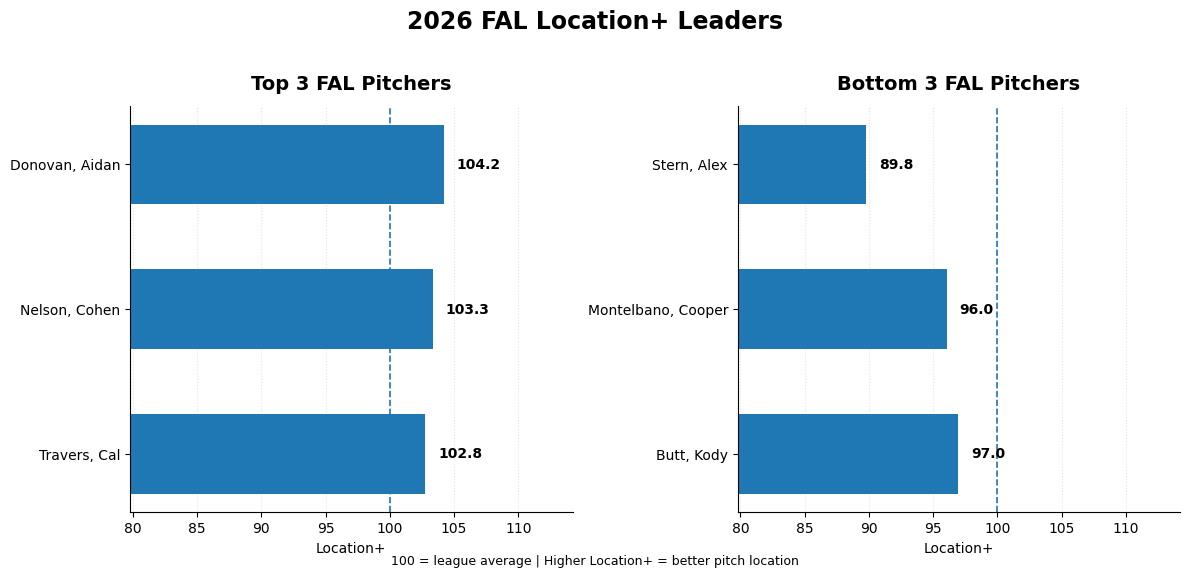

In [ ]:
def create_fal_location_plus_graphic(df: pd.DataFrame) -> None:

    df = add_team(df)

    fal_df = df.loc[
        df["PitcherTeam"].astype(str).eq(TEAM_FILTER)
        & df["Season"].eq(2026)
    ].copy()

    pitcher_summary = aggregate_scores(
        fal_df,
        ["Pitcher", "PitcherTeam"],
        MIN_PITCHES_PITCHER,
    )

    if pitcher_summary["Pitcher"].nunique() < 6:
        print(
            f"\nNot enough 2026 FAL pitchers for Top 3 / Bottom 3 graphic. "
            f"Found {pitcher_summary['Pitcher'].nunique()} pitchers."
        )
        return

    top_3 = (
        pitcher_summary.nlargest(3, "Location+")
        .sort_values("Location+", ascending=True)
        .copy()
    )

    bottom_3 = (
        pitcher_summary.nsmallest(3, "Location+")
        .sort_values("Location+", ascending=False)
        .copy()
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5.5)
    )

    min_value = min(
        top_3["Location+"].min(),
        bottom_3["Location+"].min()
    )

    max_value = max(
        top_3["Location+"].max(),
        bottom_3["Location+"].max()
    )

    x_min = max(50, min_value - 10)
    x_max = max(110, max_value + 10)

    ax = axes[0]

    bars = ax.barh(
        top_3["Pitcher"],
        top_3["Location+"],
        height=0.55
    )

    ax.axvline(
        100,
        linestyle="--",
        linewidth=1.2
    )

    ax.set_title(
        "Top 3 FAL Pitchers",
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel(
        "Location+",
        fontsize=10
    )

    ax.set_xlim(x_min, x_max)

    ax.tick_params(
        axis="y",
        labelsize=10
    )

    for bar, value in zip(
        bars,
        top_3["Location+"]
    ):
        ax.text(
            value + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    ax = axes[1]

    bars = ax.barh(
        bottom_3["Pitcher"],
        bottom_3["Location+"],
        height=0.55
    )

    ax.axvline(
        100,
        linestyle="--",
        linewidth=1.2
    )

    ax.set_title(
        "Bottom 3 FAL Pitchers",
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel(
        "Location+",
        fontsize=10
    )

    ax.set_xlim(x_min, x_max)

    ax.tick_params(
        axis="y",
        labelsize=10
    )

    for bar, value in zip(
        bars,
        bottom_3["Location+"]
    ):
        ax.text(
            value + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    fig.suptitle(
        "2026 FAL Location+ Leaders",
        fontsize=17,
        fontweight="bold",
        y=1.02
    )

    fig.text(
        0.5,
        0.01,
        "100 = league average | Higher Location+ = better pitch location",
        ha="center",
        fontsize=9
    )

    for ax in axes:

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.grid(
            axis="x",
            linestyle=":",
            alpha=0.35
        )

        ax.set_axisbelow(True)

    plt.tight_layout()

    plt.show()

    plt.close()


create_fal_location_plus_graphic(scored)